# OPTIMIZATION METHODS FOR DATA SCIENCE  
## FINAL PROJECT - PART 2: Support Vector Machines

**Team Members:**  
* **Asia Montico**, 1966494
* **Jacopo Caldana**, [Insert ID]  

---
# 1. Introduction

This notebook addresses a **binary gender classification** task using the dataset **GENDER_CLASSIFICATION.csv**.  
Each sample is represented by a **ResNet feature vector**, and the target is a binary label (0/1).  
We train and evaluate Support Vector Machine classifiers and compare two optimization strategies.  
All results are reported on a held‑out test set.





## 1.2 Setup (Libraries and Reproducibility)

We import the required libraries for numerical computation, optimization, and evaluation.  
CVXOPT is used for the dual quadratic program. We also set a fixed random seed.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix

import cvxopt
from cvxopt import matrix, solvers

# Import from the functions file
from functions_2i_montico_caldana import (
    rbf_kernel,
    solve_svm_dual_cvxopt,
    svm_predict,
    cross_validate_svm,
    mvp_svm
)

sns.set_theme(style="whitegrid")
np.random.seed(42)

## 1.3 Dataset Description and Overview

The dataset consists of pre‑extracted deep features from images.  
Each **row corresponds to one image**, with the **last column storing the gender label**.  
All remaining columns are high‑dimensional features, which are well suited for SVM models.

First, we load the dataset from the raw GitHub URL and save it locally, so the notebook can be run without any modification. Then we visualize the dataset to check class balance and feature scale.
This step is useful to validate that the dataset is not severely imbalanced and that feature values are well‑behaved.

Loaded local file: GENDER_CLASSIFICATION.csv
     feat_1    feat_2    feat_3    feat_4    feat_5    feat_6    feat_7  \
0 -0.900846  0.102587 -0.397814  0.112796  2.588096 -0.192754 -0.968311   
1 -0.838868  0.039976 -0.387101  0.055413  2.066874 -0.226948 -0.947416   
2 -0.814961 -0.010184 -0.397147  0.092713  1.897454 -0.269387 -0.945285   
3 -0.110470  0.027849 -0.044310 -0.005343  0.177831 -0.232092 -0.562700   
4 -0.626313 -0.091985 -0.373756 -0.005083  1.172486 -0.314868 -0.885046   

     feat_8    feat_9   feat_10  ...   feat_24   feat_25   feat_26   feat_27  \
0 -0.490886 -0.872099 -0.288411  ...  2.541431  1.739102  0.166066  4.584869   
1 -0.472817 -0.855387 -0.207101  ...  1.991721  1.259745  0.065058  3.019790   
2 -0.449579 -0.849705 -0.151179  ...  1.822978  1.105511  0.065353  2.500681   
3 -0.400713 -0.552356  0.037349  ... -0.098367 -0.370318 -0.123008 -0.861314   
4 -0.412587 -0.818729 -0.012022  ...  1.030348  0.421886 -0.068029  0.258984   

    feat_28   feat_29  

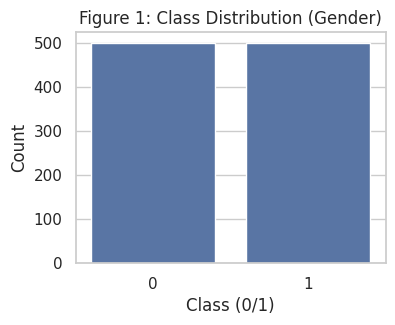

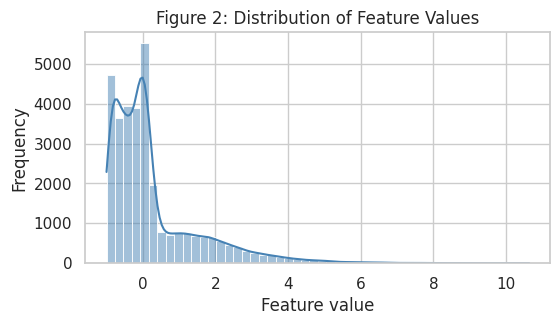

In [12]:
# Load dataset
local_filename = "GENDER_CLASSIFICATION.csv"
github_url = "https://raw.githubusercontent.com/JacopoCaldana/Age_Gender_Ethicity_classification/314009eecb765344d56d3f82e48a9c65eaa0547c/dataset/GENDER_CLASSIFICATION.csv"

try:
    df = pd.read_csv(local_filename)
    print("Loaded local file:", local_filename)
except:
    df = pd.read_csv(github_url)
    df.to_csv(local_filename, index=False)
    print("Downloaded and saved:", local_filename)

print(df.head())
print("Dataset shape:", df.shape)

# Target vector (raw labels)
y_raw = df.iloc[:, -1].to_numpy(dtype=int)

# Class distribution
plt.figure(figsize=(4,3))
sns.countplot(x=y_raw)
plt.title("Figure 1: Class Distribution (Gender)")
plt.xlabel("Class (0/1)")
plt.ylabel("Count")
plt.show()

# Feature value distribution
X_raw = df.iloc[:, :-1].to_numpy(dtype=float)

plt.figure(figsize=(6,3))
sns.histplot(X_raw.flatten(), bins=50, kde=True, color="steelblue")
plt.title("Figure 2: Distribution of Feature Values")
plt.xlabel("Feature value")
plt.ylabel("Frequency")
plt.show()


## 1.4 Theoretical Background (SVM Fundamentals)

### SVM Intuition: Maximum Margin Classifier  
Support Vector Machines are supervised models for binary classification.  
Their goal is to find a separating hyperplane that **maximizes the margin** between the two classes.  
A larger margin usually improves generalization because the classifier becomes less sensitive to small perturbations in the data.  
Only the samples that lie on the margin boundaries, called **support vectors**, actually define the optimal solution.

### Dual Formulation  
Instead of solving the primal problem, we use the **dual formulation**, which is a convex quadratic program.  
The dual objective is:

$$
\max_{\alpha}\ \sum_i \alpha_i - \frac{1}{2}\sum_{i,j}\alpha_i\alpha_j y_i y_j K(x_i,x_j)
$$

with constraints:

$$
0 \le \alpha_i \le C,\qquad \sum_i \alpha_i y_i = 0
$$

Here, the parameter $C$ controls the trade‑off between margin size and classification errors.

### Kernel Trick  
The dual formulation allows the use of **kernel functions** to model non‑linear boundaries.  
Two common choices are:

- **Linear kernel:** $K(x_i,x_j)=x_i^\top x_j$  
- **RBF (Gaussian) kernel:** $K(x_i,x_j)=\exp(-\gamma\|x_i-x_j\|^2)$  

In the RBF case, $\gamma$ controls the locality of the influence of each point:  
larger $\gamma$ produces a more flexible boundary, while smaller $\gamma$ yields a smoother one.

### Decision Function  
Once the optimal multipliers $\alpha$ are found, predictions are made using:

$$
f(x)=\text{sign}\left(\sum_i \alpha_i y_i K(x_i,x)+b\right)
$$

The sign of $f(x)$ determines the predicted class.
### MVP Decomposition Method (SMO-style)

The **Most Violating Pair (MVP)** method is a specific decomposition strategy where the working set size is restricted to $q=2$. This approach, often referred to as Sequential Minimal Optimization (SMO), allows for an analytical solution of the subproblem at each iteration, avoiding the need for numerical QP solvers.

The algorithm relies on the **Karush-Kuhn-Tucker (KKT)** optimality conditions. For the dual SVM problem, the optimality conditions require that there exists a scalar $b$ such that for all $i=1, \dots, n$:

$$
\begin{cases}
y_i f(x_i) \ge 1 & \text{if } \alpha_i = 0 \\
y_i f(x_i) = 1 & \text{if } 0 < \alpha_i < C \\
y_i f(x_i) \le 1 & \text{if } \alpha_i = C
\end{cases}
$$

where $f(x_i) = \sum_j \alpha_j y_j K(x_i, x_j) + b$.

To identify the variables that violate these conditions, we define the gradient of the objective function (excluding $b$) as $g_i = \sum_j \alpha_j y_j K(x_i, x_j) - y_i$.
The algorithm selects two indices $(i, j)$ at each step based on the definition of two sets, $I_{up}$ and $I_{low}$:

*   **$I_{up}$**: Indices capable of increasing the objective function.
    $$ I_{up} = \{ i \mid (\alpha_i < C \land y_i = 1) \lor (\alpha_i > 0 \land y_i = -1) \} $$
*   **$I_{low}$**: Indices capable of decreasing the objective function.
    $$ I_{low} = \{ i \mid (\alpha_i < C \land y_i = -1) \lor (\alpha_i > 0 \land y_i = 1) \} $$

The **Most Violating Pair** is chosen as:
$$ i = \arg \max_{k \in I_{up}} (-y_k g_k), \quad j = \arg \min_{k \in I_{low}} (-y_k g_k) $$

The algorithm proceeds by updating $\alpha_i$ and $\alpha_j$ analytically to satisfy the constraint $\sum \alpha y = 0$ while maximizing the dual objective, repeating until the maximal violation falls below a tolerance threshold.

## 1.5 Preprocessing

We convert labels to $\{-1, +1\}$ as required by the SVM dual formulation, then split the data into training and test sets.  
We standardize using only training statistics to prevent data leakage.

In [13]:
X = df.iloc[:, :-1].to_numpy(dtype=float)
y_raw = df.iloc[:, -1].to_numpy(dtype=int)

# Convert labels to {-1, +1}
y = np.where(y_raw == 1, 1, -1)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Standardization
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (800, 32)
Test shape: (200, 32)


---
# 2. Q2 — Dual SVM with CVXOPT

In Q2 we solve the SVM dual problem using a quadratic programming solver (CVXOPT).  
We apply **5‑fold cross validation** to select the best hyperparameters:  
this is a standard choice that provides a good trade‑off between stability of the estimate and computational cost.  
We then train the final model on the full training set.  
For the kernel we choose the **RBF (Gaussian) kernel**, because it can model nonlinear decision boundaries in high‑dimensional feature spaces.


## 2.1 Final Training and Evaluation

We train using the best $C$ and $\gamma$ found via CV.  
We report training accuracy, test accuracy, the confusion matrix, optimization time, and iterations.


In [14]:
C_grid = [0.1, 1, 10]
gamma_grid = [0.01, 0.1, 1]

start_cv = time.time()
(best_C, best_gamma), best_val_acc = cross_validate_svm(X_train, y_train, C_grid, gamma_grid)
cv_time = time.time() - start_cv

print("Best C:", best_C)
print("Best gamma:", best_gamma)
print("Validation Accuracy:", best_val_acc)
print("CV Time:", cv_time)

start_train = time.time()
alpha, b, sol = solve_svm_dual_cvxopt(X_train, y_train, best_C, best_gamma)
train_time = time.time() - start_train

y_train_pred = svm_predict(X_train, y_train, alpha, b, X_train, best_gamma)
y_test_pred = svm_predict(X_train, y_train, alpha, b, X_test, best_gamma)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Optimization iterations:", sol['iterations'])
print("Final dual objective:", sol['primal objective'])

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

Best C: 0.1
Best gamma: 0.1
Validation Accuracy: 0.9175000000000001
CV Time: 31.597565174102783
Train Accuracy: 0.91625
Test Accuracy: 0.925
Optimization iterations: 16
Final dual objective: -18.20172870219692
Confusion Matrix:
 [[93  7]
 [ 8 92]]


---

# 3. Q3 — MVP Decomposition Method (q = 2)

In Q3 we solve the SVM dual problem using the **Most Violating Pair (MVP)** decomposition method.  
At each iteration, the algorithm selects the pair of variables that most violates the KKT conditions  
and updates them analytically while keeping all other variables fixed.  
This leads to a lightweight optimization step (subproblem size $q=2$) and makes the method scalable.  
We use the same RBF kernel and the same $(C,\gamma)$ values selected in Q2,  
so that performance differences are due to the optimization strategy rather than hyperparameter tuning.  
We report training accuracy, test accuracy, iterations, and CPU time.

## 3.1 Training & Evaluation

We evaluate the MVP method using the same $C$ and $\gamma$ selected previously.


In [17]:
# Updated call in the notebook
start = time.time()
# Note: Ensure mvp_svm returns alpha, b, iterations
alpha_mvp, b_mvp, iters = mvp_svm(X_train, y_train, best_C, best_gamma)
mvp_time = time.time() - start

# Prediction Logic remains the same
y_train_pred_mvp = svm_predict(X_train, y_train, alpha_mvp, b_mvp, X_train, best_gamma)
y_test_pred_mvp = svm_predict(X_train, y_train, alpha_mvp, b_mvp, X_test, best_gamma)


train_acc_mvp = accuracy_score(y_train, y_train_pred_mvp)
test_acc_mvp = accuracy_score(y_test, y_test_pred_mvp)

print("MVP Train Accuracy:", train_acc_mvp)
print("MVP Test Accuracy:", test_acc_mvp)
print("Iterations:", iters)
print("Training Time:", mvp_time)

MVP Train Accuracy: 0.91625
MVP Test Accuracy: 0.925
Iterations: 529
Training Time: 0.0662848949432373


---


# 4. Figures (Confusion Matrices & Accuracy Comparison)

These figures summarize the classification performance of Q2 and Q3.


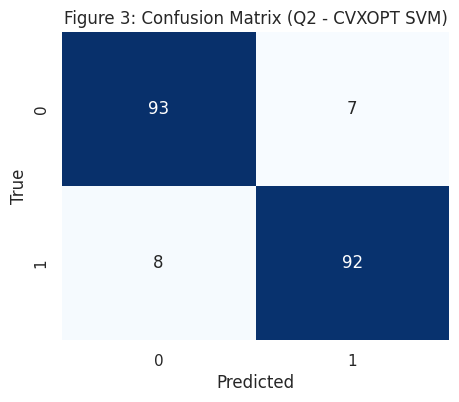

In [8]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Figure 3: Confusion Matrix (Q2 - CVXOPT SVM)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

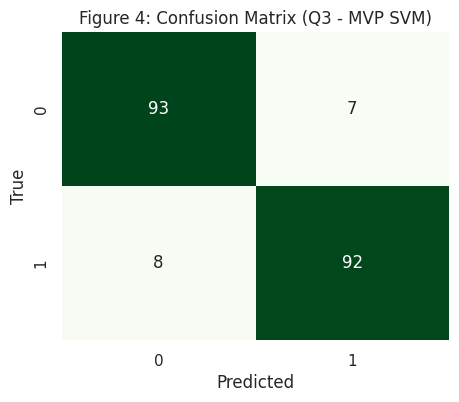

In [9]:
cm_mvp = confusion_matrix(y_test, y_test_pred_mvp)

plt.figure(figsize=(5,4))
sns.heatmap(cm_mvp, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.title("Figure 4: Confusion Matrix (Q3 - MVP SVM)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

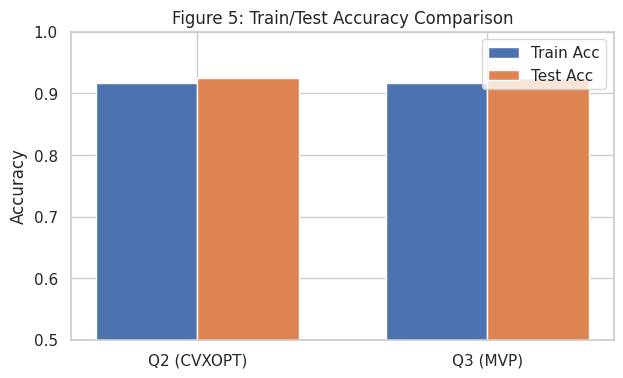

In [10]:
labels = ["Q2 (CVXOPT)", "Q3 (MVP)"]
train_scores = [train_acc, train_acc_mvp]
test_scores = [test_acc, test_acc_mvp]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - width/2, train_scores, width, label="Train Acc")
plt.bar(x + width/2, test_scores, width, label="Test Acc")
plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Figure 5: Train/Test Accuracy Comparison")
plt.legend()
plt.ylim(0.5, 1.0)
plt.show()